In [209]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [211]:
sns.set(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [213]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Kích thước train:", train.shape)
print("Kích thước test:", test.shape)

train.head()

Kích thước train: (2000, 21)
Kích thước test: (1000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0,1


In [215]:
rename_map = {
    "battery_power": "battery_power",
    "blue": "bluetooth",
    "clock_speed": "clock_speed",
    "dual_sim": "dual_sim",
    "fc": "front_camera",
    "four_g": "4_g",
    "int_memory": "internal_memory",
    "m_dep": "thickness",
    "mobile_wt": "weight",
    "n_cores": "cpu_cores",
    "pc": "rear_camera",
    "px_height": "resolution_height",
    "px_width": "resolution_width",
    "ram": "ram",
    "sc_h": "screen_height",
    "sc_w": "screen_width",
    "talk_time": "talk_time",
    "three_g": "3_g",
    "touch_screen": "touch_screen",
    "wifi": "wifi",
    "price_range": "price_range"
}

train = train.rename(columns=rename_map)
test = test.rename(columns=rename_map)

print("Tên cột mới của train:")
print(train.columns.tolist())

print("\nTên cột mới của test:")
print(test.columns.tolist())

Tên cột mới của train:
['battery_power', 'bluetooth', 'clock_speed', 'dual_sim', 'front_camera', '4_g', 'internal_memory', 'thickness', 'weight', 'cpu_cores', 'rear_camera', 'resolution_height', 'resolution_width', 'ram', 'screen_height', 'screen_width', 'talk_time', '3_g', 'touch_screen', 'wifi', 'price_range']

Tên cột mới của test:
['id', 'battery_power', 'bluetooth', 'clock_speed', 'dual_sim', 'front_camera', '4_g', 'internal_memory', 'thickness', 'weight', 'cpu_cores', 'rear_camera', 'resolution_height', 'resolution_width', 'ram', 'screen_height', 'screen_width', 'talk_time', '3_g', 'touch_screen', 'wifi']


In [217]:
feature_description = {
    "battery_power": "Dung lượng pin",
    "bluetooth": "Có bluetooth hay không",
    "clock_speed": "Tốc độ xung nhịp CPU",
    "dual_sim": "Hỗ trợ 2 SIM",
    "front_camera": "Độ phân giải camera trước",
    "4_g": "Hỗ trợ 4G",
    "internal_memory": "Bộ nhớ trong",
    "thickness": "Độ dày điện thoại",
    "weight": "Khối lượng điện thoại",
    "cpu_cores": "Số nhân CPU",
    "rear_camera": "Độ phân giải camera sau",
    "resolution_height": "Độ phân giải chiều cao",
    "resolution_width": "Độ phân giải chiều rộng",
    "ram": "Dung lượng RAM",
    "screen_height": "Chiều cao màn hình",
    "screen_width": "Chiều rộng màn hình",
    "talk_time": "Thời gian đàm thoại",
    "3_g": "Hỗ trợ 3G",
    "touch_screen": "Có màn hình cảm ứng",
    "wifi": "Có wifi",
    "price_range": "Nhóm giá điện thoại"
}

feature_description_df = pd.DataFrame(
    feature_description.items(),
    columns=["Feature", "Meaning"]
)

display(feature_description_df)

,Feature,Meaning
0,battery_power,Dung lượng pin
1,bluetooth,Có bluetooth hay không
2,clock_speed,Tốc độ xung nhịp CPU
3,dual_sim,Hỗ trợ 2 SIM
4,front_camera,Độ phân giải camera trước
5,4_g,Hỗ trợ 4G
6,internal_memory,Bộ nhớ trong
7,thickness,Độ dày điện thoại
8,weight,Khối lượng điện thoại
9,cpu_cores,Số nhân CPU


In [219]:
print("=== THÔNG TIN TRAIN ===")
print(train.info())

print("\n=== THỐNG KÊ MÔ TẢ TRAIN ===")
display(train.describe())

print("\n=== CÁC CỘT TRONG TRAIN ===")
print(train.columns.tolist())

=== THÔNG TIN TRAIN ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   battery_power      2000 non-null   int64  
 1   bluetooth          2000 non-null   int64  
 2   clock_speed        2000 non-null   float64
 3   dual_sim           2000 non-null   int64  
 4   front_camera       2000 non-null   int64  
 5   4_g                2000 non-null   int64  
 6   internal_memory    2000 non-null   int64  
 7   thickness          2000 non-null   float64
 8   weight             2000 non-null   int64  
 9   cpu_cores          2000 non-null   int64  
 10  rear_camera        2000 non-null   int64  
 11  resolution_height  2000 non-null   int64  
 12  resolution_width   2000 non-null   int64  
 13  ram                2000 non-null   int64  
 14  screen_height      2000 non-null   int64  
 15  screen_width       2000 non-null   int64  
 16  

,battery_power,bluetooth,clock_speed,dual_sim,front_camera,4_g,internal_memory,thickness,weight,cpu_cores,rear_camera,resolution_height,resolution_width,ram,screen_height,screen_width,talk_time,3_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,9.916500,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,6.064315,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,0.000000,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,5.000000,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,10.000000,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,15.000000,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,20.000000,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000



=== CÁC CỘT TRONG TRAIN ===
['battery_power', 'bluetooth', 'clock_speed', 'dual_sim', 'front_camera', '4_g', 'internal_memory', 'thickness', 'weight', 'cpu_cores', 'rear_camera', 'resolution_height', 'resolution_width', 'ram', 'screen_height', 'screen_width', 'talk_time', '3_g', 'touch_screen', 'wifi', 'price_range']


In [221]:
print("=== THÔNG TIN TEST ===")
print(test.info())

print("\n=== CÁC CỘT TRONG TEST ===")
print(test.columns.tolist())

test.head()

=== THÔNG TIN TEST ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1000 non-null   int64  
 1   battery_power      1000 non-null   int64  
 2   bluetooth          1000 non-null   int64  
 3   clock_speed        1000 non-null   float64
 4   dual_sim           1000 non-null   int64  
 5   front_camera       1000 non-null   int64  
 6   4_g                1000 non-null   int64  
 7   internal_memory    1000 non-null   int64  
 8   thickness          1000 non-null   float64
 9   weight             1000 non-null   int64  
 10  cpu_cores          1000 non-null   int64  
 11  rear_camera        1000 non-null   int64  
 12  resolution_height  1000 non-null   int64  
 13  resolution_width   1000 non-null   int64  
 14  ram                1000 non-null   int64  
 15  screen_height      1000 non-null   int64  
 16  sc

,id,battery_power,bluetooth,clock_speed,dual_sim,front_camera,4_g,internal_memory,thickness,weight,cpu_cores,rear_camera,resolution_height,resolution_width,ram,screen_height,screen_width,talk_time,3_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,3,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,5,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,3,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,8,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,6,18,749,810,1773,15,8,7,1,0,1


In [223]:
print("Thiếu dữ liệu trong train:")
display(train.isnull().sum())

print("Thiếu dữ liệu trong test:")
display(test.isnull().sum())

Thiếu dữ liệu trong train:


battery_power        0
bluetooth            0
clock_speed          0
dual_sim             0
front_camera         0
4_g                  0
internal_memory      0
thickness            0
weight               0
cpu_cores            0
rear_camera          0
resolution_height    0
resolution_width     0
ram                  0
screen_height        0
screen_width         0
talk_time            0
3_g                  0
touch_screen         0
wifi                 0
price_range          0
dtype: int64

Thiếu dữ liệu trong test:


id                   0
battery_power        0
bluetooth            0
clock_speed          0
dual_sim             0
front_camera         0
4_g                  0
internal_memory      0
thickness            0
weight               0
cpu_cores            0
rear_camera          0
resolution_height    0
resolution_width     0
ram                  0
screen_height        0
screen_width         0
talk_time            0
3_g                  0
touch_screen         0
wifi                 0
dtype: int64

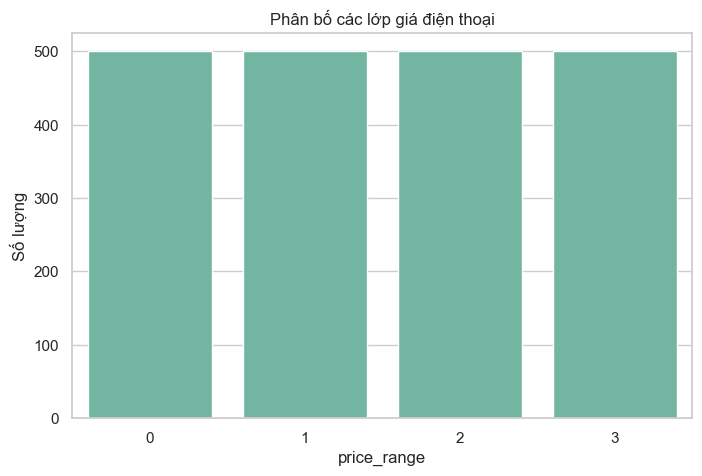

price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64


In [225]:
plt.figure(figsize=(8,5))
sns.countplot(x="price_range", data=train)
plt.title("Phân bố các lớp giá điện thoại")
plt.xlabel("price_range")
plt.ylabel("Số lượng")
plt.show()

print(train["price_range"].value_counts().sort_index())

In [227]:
X = train.drop(columns=["price_range"])
y = train["price_range"]

if "id" in X.columns:
    X = X.drop(columns=["id"])

if "id" in test.columns:
    test_id = test["id"]
    test_features = test.drop(columns=["id"])
else:
    test_id = pd.Series(range(len(test)), name="id")
    test_features = test.copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("test_features shape:", test_features.shape)

X shape: (2000, 20)
y shape: (2000,)
test_features shape: (1000, 20)


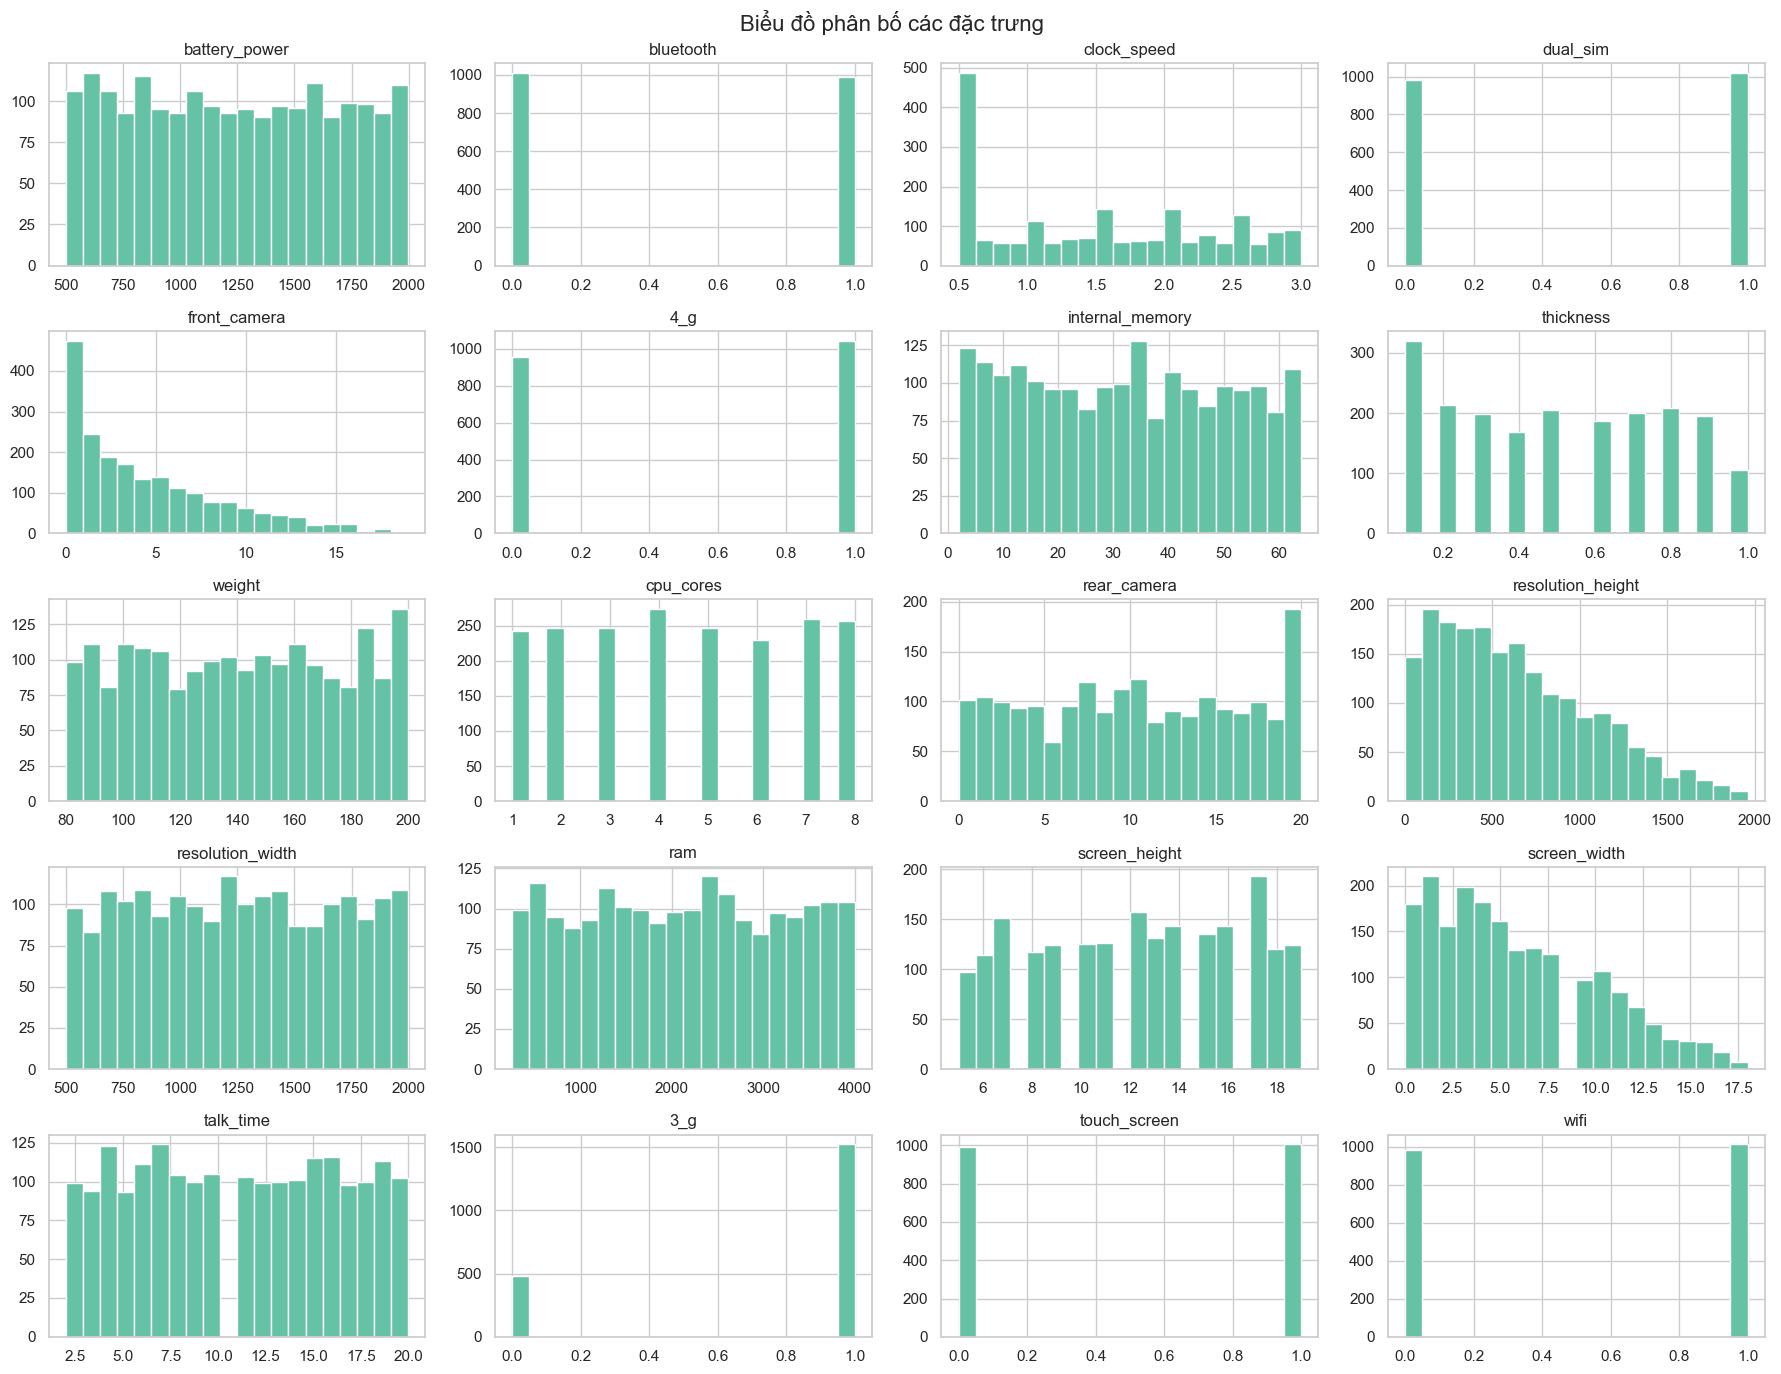

In [229]:
X.hist(figsize=(18, 14), bins=20)
plt.suptitle("Biểu đồ phân bố các đặc trưng", fontsize=16)
plt.tight_layout()
plt.show()

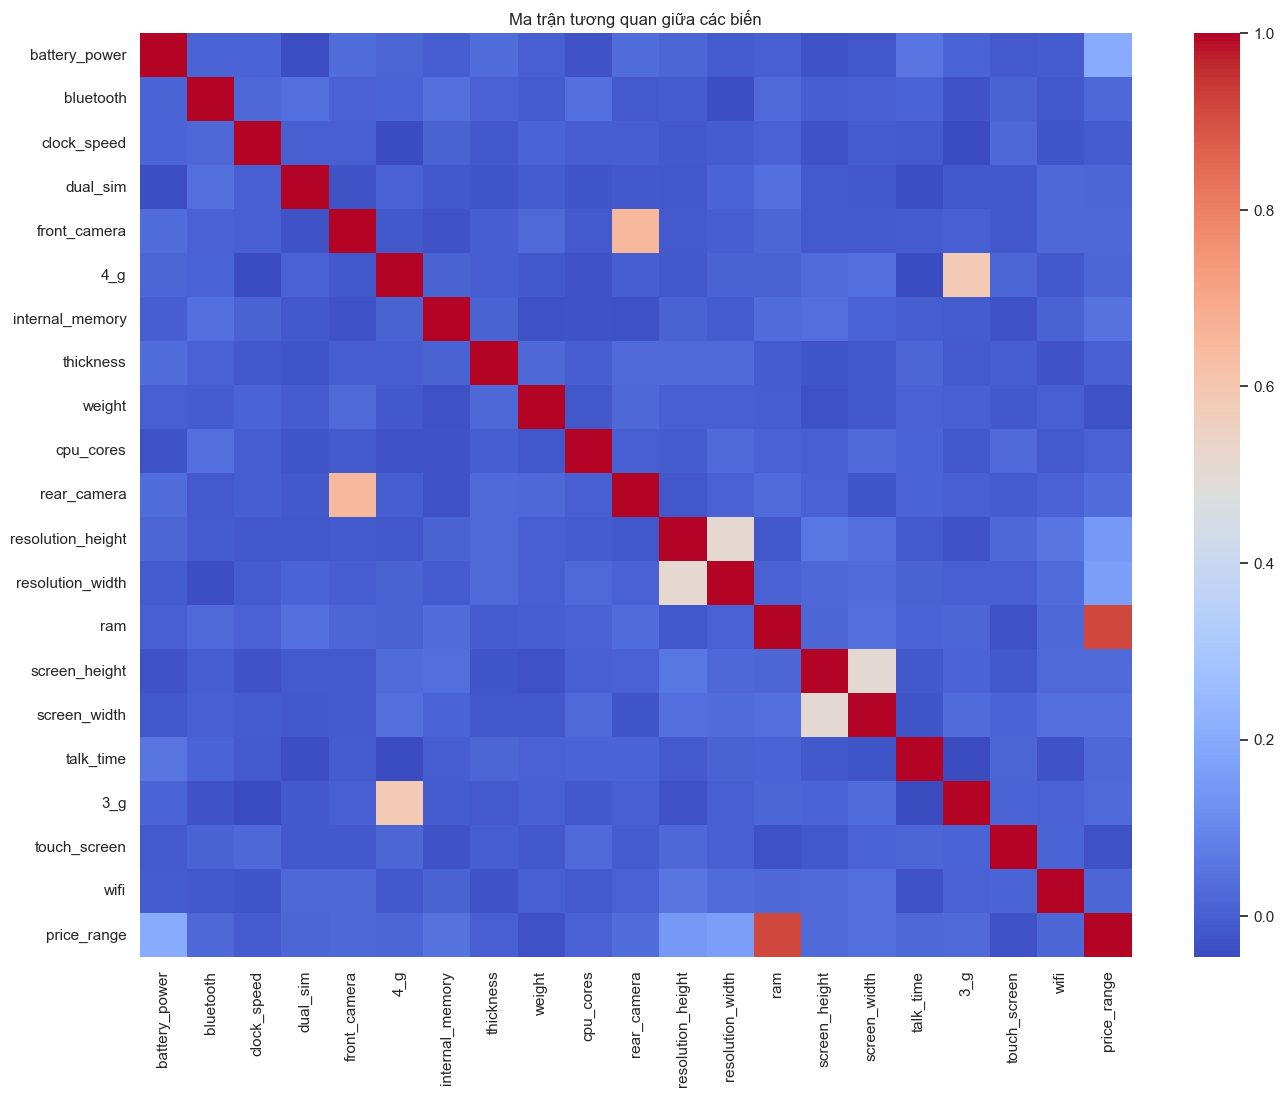

In [230]:
plt.figure(figsize=(16, 12))
corr = train.corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Ma trận tương quan giữa các biến")
plt.show()

In [231]:
corr_target = train.corr()["price_range"].sort_values(ascending=False)
display(corr_target)

price_range          1.000000
ram                  0.917046
battery_power        0.200723
resolution_width     0.165818
resolution_height    0.148858
internal_memory      0.044435
screen_width         0.038711
rear_camera          0.033599
3_g                  0.023611
screen_height        0.022986
front_camera         0.021998
talk_time            0.021859
bluetooth            0.020573
wifi                 0.018785
dual_sim             0.017444
4_g                  0.014772
cpu_cores            0.004399
thickness            0.000853
clock_speed         -0.006606
weight              -0.030302
touch_screen        -0.030411
Name: price_range, dtype: float64

In [232]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (1600, 20)
X_val: (400, 20)
y_train: (1600,)
y_val: (400,)


In [233]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_val)

print("Decision Tree Accuracy:", accuracy_score(y_val, y_pred_dt))
print(classification_report(y_val, y_pred_dt))

Decision Tree Accuracy: 0.83
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       100
           1       0.78      0.74      0.76       100
           2       0.75      0.80      0.77       100
           3       0.92      0.86      0.89       100

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



In [234]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

print("Random Forest Accuracy:", accuracy_score(y_val, y_pred_rf))
print(classification_report(y_val, y_pred_rf))

Random Forest Accuracy: 0.8775
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       100
           1       0.81      0.84      0.82       100
           2       0.82      0.79      0.81       100
           3       0.94      0.93      0.93       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



In [235]:
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=5000, random_state=42))
])

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)

print("Logistic Regression Accuracy:", accuracy_score(y_val, y_pred_lr))
print(classification_report(y_val, y_pred_lr))

Logistic Regression Accuracy: 0.965
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.96      0.96      0.96       100
           2       0.95      0.94      0.94       100
           3       0.96      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400



In [236]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_val, y_pred_dt),
        accuracy_score(y_val, y_pred_rf),
        accuracy_score(y_val, y_pred_lr)
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)
display(results)

,Model,Accuracy
2,Logistic Regression,0.9650
1,Random Forest,0.8775
0,Decision Tree,0.8300


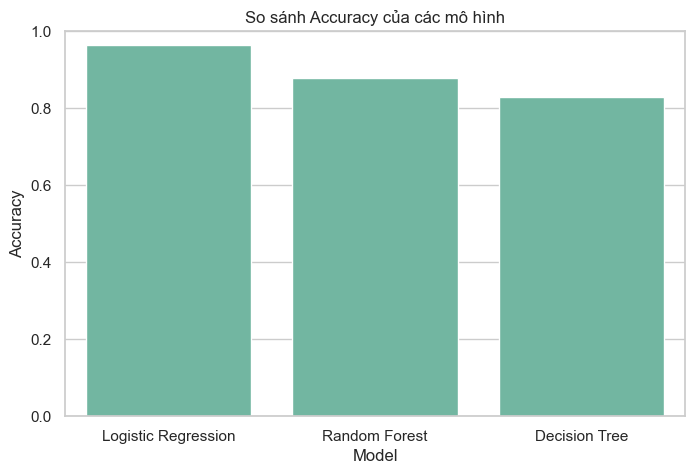

In [237]:
plt.figure(figsize=(8,5))
sns.barplot(data=results, x="Model", y="Accuracy")
plt.title("So sánh Accuracy của các mô hình")
plt.ylim(0, 1)
plt.show()

In [262]:
best_model = rf_model

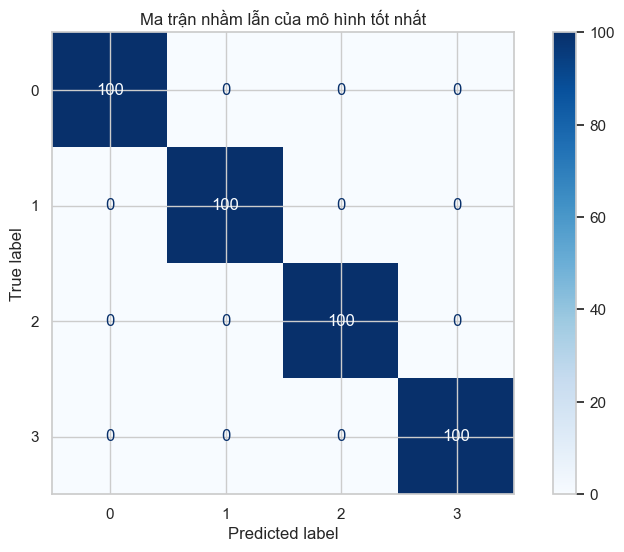

In [264]:
y_pred_best = best_model.predict(X_val)

cm = confusion_matrix(y_val, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Ma trận nhầm lẫn của mô hình tốt nhất")
plt.show()

,Feature,Importance
13,ram,0.482913
0,battery_power,0.072960
12,resolution_width,0.057762
11,resolution_height,0.055650
8,weight,0.038956
6,internal_memory,0.035032
16,talk_time,0.030427
10,rear_camera,0.029901
15,screen_width,0.028026
2,clock_speed,0.027638


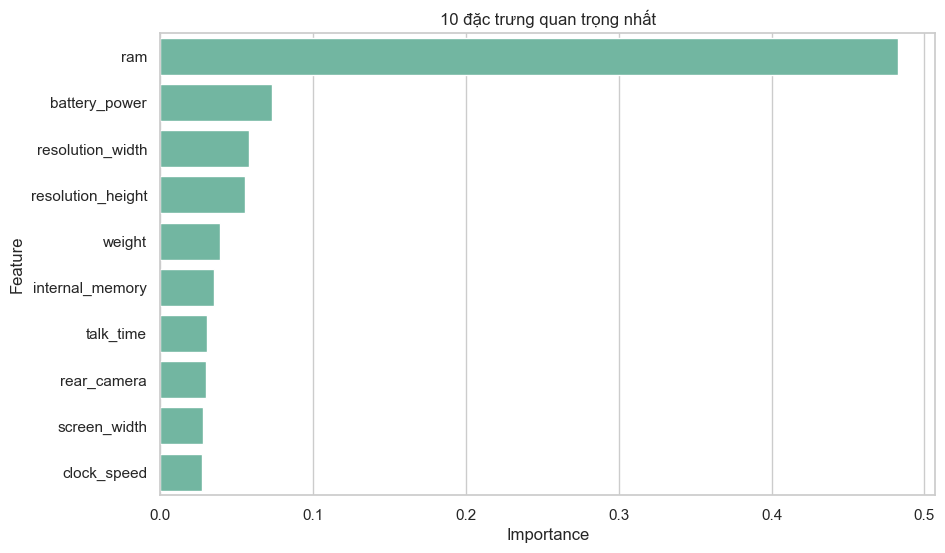

In [240]:
if hasattr(best_model, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    display(feature_importance.head(10))

    plt.figure(figsize=(10,6))
    sns.barplot(data=feature_importance.head(10), x="Importance", y="Feature")
    plt.title("10 đặc trưng quan trọng nhất")
    plt.show()

In [242]:
best_model.fit(X, y)

RandomForestClassifier(n_estimators=200, random_state=42)

In [272]:
test_pred = best_model.predict(test_features)

submission = pd.DataFrame({
    "id": test_id,
    "price_range": test_pred
})

submission.head()

,id,price_range
0,1,3
1,2,3
2,3,2
3,4,3
4,5,1


In [280]:
submission.to_csv("submission.csv", index=False)
print("Đã lưu file submission.csv")

Đã lưu file submission.csv


In [249]:
print("Kết quả so sánh mô hình:")
display(results)

Kết quả so sánh mô hình:


,Model,Accuracy
2,Logistic Regression,0.9650
1,Random Forest,0.8775
0,Decision Tree,0.8300
